#### **Lab 9. SVD(특이값 분해)를 이용한 이미지 압축**

모든 행렬은 로 분해됩니다. 의 중요도 순으로 데이터를 남겨 정보를 압축합니다.

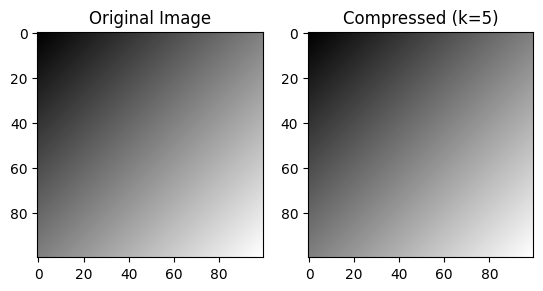

In [ ]:
# 0~255 사이의 그라데이션 이미지 생성 (100x100)
img = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        img[i, j] = i + j # 대각선 그라데이션 패턴

# SVD 수행
U, S, Vt = np.linalg.svd(img)

# 상위 k개의 특이값만 사용하여 이미지 복원
k = 5
reconstructed_img = np.dot(U[:, :k] * S[:k], Vt[:k, :])

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.title(f"Compressed (k={k})")
plt.show()

#### **Lab 10. PCA (주성분 분석) 파이프라인 완성**

데이터의 공분산 행렬을 구하고, 고유벡터 축으로 데이터를 투영하여 차원을 축소합니다.

In [ ]:
# [데이터 생성] 키와 몸무게처럼 상관관계가 있는 데이터
np.random.seed(0)
X = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

# 1. 중심화 (Mean Centering)
X_centered = X - X.mean(axis=0)

# 2. 공분산 행렬 계산
cov_mat = np.cov(X_centered.T)

# 3. 고유값 분해
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# 4. 정렬 (설명력이 높은 순서대로)
idx = eigen_vals.argsort()[::-1]
eigen_vecs = eigen_vecs[:, idx]

# 5. 투영 (Projection) - 2차원을 1차원으로 축소
# 가장 중요한 주성분(PC1) 하나만 선택
pc1 = eigen_vecs[:, 0]
X_projected = X_centered.dot(pc1)

print("원본 데이터 Shape:", X.shape)
print("차원 축소된 데이터 Shape:", X_projected.shape)
# (200, 2) -> (200,) 로 압축됨

원본 데이터 Shape: (200, 2)
차원 축소된 데이터 Shape: (200,)
